In [10]:
import requests
import csv
import pandas as pd
import math
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import time
import random
from datetime import datetime, date
import statistics
import requests
from scipy.stats import skew, kurtosis
from scipy import stats
import pandas as pd
from statsmodels.tsa.stattools import adfuller
from scipy import stats
from scipy.stats import johnsonsu
from scipy.optimize import minimize
from scipy.stats import norm

In [11]:
def get_data(ticker, size='full', date_filter=None):
    """ Retrieve time series data for the price of a security in data frame format
        Sorts so that first date is first index, filters on date if given, renames columns and converts datatypes

    Args:
        ticker (string): The ticker for the security to pull data from
        size (string): 'full' since 1999, 'compact' is last 100 trading days
        date_filter (date string): Filters  data to  keep data only the filter date onward

    Returns:
        df: A dataframe with open, close, high, low, adj close price, volume, split coef, date
    """
    key='&apikey=ZKMMTO1ATDBLXH2K' # API Key
    api_ticker=f'&symbol={ticker}' # Ticker
    endpoint='function=TIME_SERIES_DAILY_ADJUSTED' # Called 'function', the dataset we want
    size=f'&outputsize={size}'
    web='https://www.alphavantage.co/query?'
    url =web+endpoint+api_ticker+size+key

    r = requests.get(url)
    # print(r.status_code) # 200 good, 400 bad
    data = r.json()

    # print(data.keys()) #printing the keys
    meta = data['Meta Data']
    time_series_data = data['Time Series (Daily)']

    ts_df = pd.DataFrame.from_dict(time_series_data, orient='index').reset_index().rename(columns={'index': 'Date'})
    clean_cols_dict = {'1. open': 'Open', '2. high': 'High', '3. low': 'Low', '4. close': 'Close', # Dictionary to convert the names of the columns
                '5. adjusted close': 'Adj Close', '6. volume': 'Volume', '7. dividend amount': 'Dividend', '8. split coefficient': 'Split Coef'}
    ts_df = ts_df.rename(columns=clean_cols_dict)

    ts_df['Date'] = pd.to_datetime(ts_df['Date'])
    if date_filter is not None:
        date_filter = pd.to_datetime(date_filter)
        ts_df = ts_df[ts_df['Date'] >= date_filter]


    ts_df = ts_df.sort_values(by='Date', ascending=True).reset_index().drop(columns='index')
    ts_df['Adj Close'] = ts_df['Adj Close'].astype('float').round(4)
    ts_df['Ticker'] = ticker
    
    return ts_df

In [12]:
def calculate_returns(df, frequency=1):
    """ Calculate the log returns of a security given a df with its prices over a time period

    Args:
        df (dataframe): A dataframe with columns Date, Ticker, Volume, and Adj Close
        frequency (int, optional): How often you want to calculate a return Defaults to 1.

    Returns:
        df: The dataframe from the start with an additional 'Log Return' column which is the log return over the interval for each row
    """
    returns_df = df[['Date', 'Ticker', 'Volume', 'Adj Close']].copy()
    returns_df['Adj Close'] = returns_df['Adj Close'].astype('float')
    returns_df['Log Return'] = np.log(
        returns_df['Adj Close'] / returns_df['Adj Close'].shift(frequency)
    )
    returns_df = returns_df.dropna()

    # If frequency > 1, keep only every `frequency`-th row
    if frequency > 1:
        returns_df = returns_df.iloc[frequency-1::frequency].reset_index(drop=True)

    return returns_df



In [16]:
euad_df = get_data('EUAD', size='full', date_filter='2021-01-01')
euad_df = euad_df[euad_df['Date'] <= pd.to_datetime('2026-01-01')]
returns_df = calculate_returns(euad_df, frequency=1).rename(columns={'Adj Close': 'Price'})
returns_df

,Date,Ticker,Volume,Price,Log Return
1,2024-10-23,EUAD,10076,24.7322,-0.012796
2,2024-10-24,EUAD,22,24.8440,0.004510
3,2024-10-25,EUAD,553,24.6802,-0.006615
4,2024-10-28,EUAD,1838,24.8137,0.005395
5,2024-10-29,EUAD,1355,24.6914,-0.004941
...,...,...,...,...,...
294,2025-12-24,EUAD,48279,42.2014,-0.001887
295,2025-12-26,EUAD,141727,42.3210,0.002830
296,2025-12-29,EUAD,322047,41.6935,-0.014938
297,2025-12-30,EUAD,200588,42.2600,0.013496


SAMPLE MEAN (daily log return)
  Point estimate:     0.001141
  Bootstrap SE:       0.000924
  95% CI:             [-0.000683, 0.002940]

ROBUST CENTER + SPREAD (median and MAD)
  (use when mean/std are noisy or outlier-driven)
  Sample median:      0.000926
  Median bootstrap SE:0.000836
  Median 95% CI:      [-0.000868, 0.002505]
  Sample MAD (raw):   0.009935
  MAD scaled (~std):  0.014730   (sample std: 0.018720)
  MAD bootstrap SE:   0.000722
  MAD 95% CI:         [0.008729, 0.011652]

SAMPLE VOLATILITY (daily std of log returns)
  Point estimate:     0.018720
  Bootstrap SE:       0.001150
  95% CI:             [0.016550, 0.021042]
  Annualized vol (%): 29.72
  Ann. vol 95% CI (%):[26.27, 33.40]
  Ann. vol bootstrap SE (%): 1.83


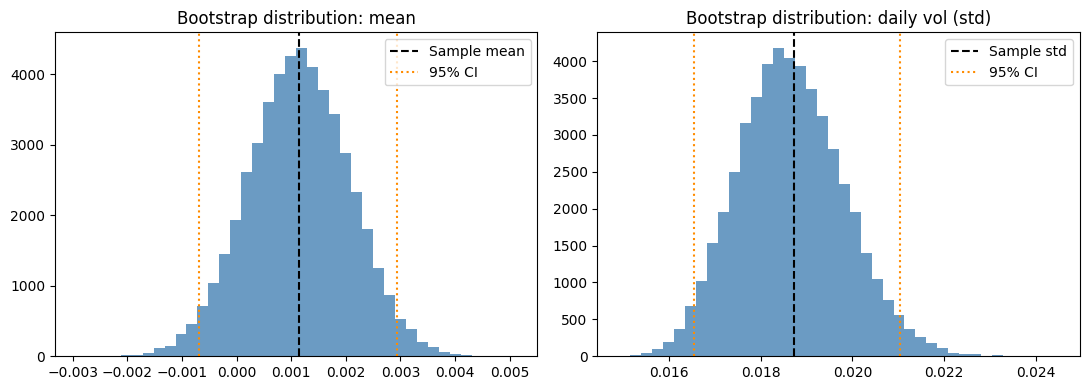

In [15]:
# Bootstrap standard errors and 95% CIs for mean and volatility (daily std of log returns)
r = returns_df['Log Return'].dropna().values
n = len(r)
B = 50000  # number of bootstrap resamples
rng = np.random.default_rng(42)

sample_mean = r.mean()
sample_std = r.std(ddof=1)  # daily volatility (sample std)

from scipy.stats import median_abs_deviation

bootstrap_means = np.empty(B)
bootstrap_stds = np.empty(B)
bootstrap_medians = np.empty(B)  # robust center (pairs with MAD when mean is noisy)
bootstrap_mads = np.empty(B)       # robust spread each resample

for b in range(B):
    idx = rng.integers(0, n, size=n)  # same length as data, with replacement
    boot_sample = r[idx]
    bootstrap_means[b] = boot_sample.mean()
    bootstrap_stds[b] = boot_sample.std(ddof=1)
    bootstrap_medians[b] = np.median(boot_sample)
    bootstrap_mads[b] = median_abs_deviation(boot_sample, scale=1.0)  # raw MAD

# SE = spread of bootstrap estimates; CI = middle 95% of bootstrap estimates
mean_se = bootstrap_means.std(ddof=1)
std_se = bootstrap_stds.std(ddof=1)
median_se = bootstrap_medians.std(ddof=1)
mad_se = bootstrap_mads.std(ddof=1)
mean_ci = np.percentile(bootstrap_means, [2.5, 97.5])
std_ci = np.percentile(bootstrap_stds, [2.5, 97.5])
median_ci = np.percentile(bootstrap_medians, [2.5, 97.5])
mad_ci = np.percentile(bootstrap_mads, [2.5, 97.5])

sample_median = np.median(r)
sample_mad = median_abs_deviation(r, scale=1.0)
sample_mad_scaled = median_abs_deviation(r, scale='normal')  # ~std if data were normal

# Annualized vol (finance convention)
sample_vol_ann = sample_std * np.sqrt(252)
boot_vol_ann = bootstrap_stds * np.sqrt(252)
vol_ann_ci = np.percentile(boot_vol_ann, [2.5, 97.5])
vol_ann_se = boot_vol_ann.std(ddof=1)

print("=" * 55)
print("SAMPLE MEAN (daily log return)")
print(f"  Point estimate:     {sample_mean:.6f}")
print(f"  Bootstrap SE:       {mean_se:.6f}")
print(f"  95% CI:             [{mean_ci[0]:.6f}, {mean_ci[1]:.6f}]")

print("\n" + "=" * 55)
print("ROBUST CENTER + SPREAD (median and MAD)")
print("  (use when mean/std are noisy or outlier-driven)")
print(f"  Sample median:      {sample_median:.6f}")
print(f"  Median bootstrap SE:{median_se:.6f}")
print(f"  Median 95% CI:      [{median_ci[0]:.6f}, {median_ci[1]:.6f}]")
print(f"  Sample MAD (raw):   {sample_mad:.6f}")
print(f"  MAD scaled (~std):  {sample_mad_scaled:.6f}   (sample std: {sample_std:.6f})")
print(f"  MAD bootstrap SE:   {mad_se:.6f}")
print(f"  MAD 95% CI:         [{mad_ci[0]:.6f}, {mad_ci[1]:.6f}]")

print("\n" + "=" * 55)
print("SAMPLE VOLATILITY (daily std of log returns)")
print(f"  Point estimate:     {sample_std:.6f}")
print(f"  Bootstrap SE:       {std_se:.6f}")
print(f"  95% CI:             [{std_ci[0]:.6f}, {std_ci[1]:.6f}]")
print(f"  Annualized vol (%): {sample_vol_ann * 100:.2f}")
print(f"  Ann. vol 95% CI (%):[{vol_ann_ci[0]*100:.2f}, {vol_ann_ci[1]*100:.2f}]")
print(f"  Ann. vol bootstrap SE (%): {vol_ann_se * 100:.2f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(bootstrap_means, bins=40, color='steelblue', alpha=0.8)
axes[0].axvline(sample_mean, color='black', linestyle='--', label='Sample mean')
axes[0].axvline(mean_ci[0], color='darkorange', linestyle=':', label='95% CI')
axes[0].axvline(mean_ci[1], color='darkorange', linestyle=':')
axes[0].set_title('Bootstrap distribution: mean')
axes[0].legend()

axes[1].hist(bootstrap_stds, bins=40, color='steelblue', alpha=0.8)
axes[1].axvline(sample_std, color='black', linestyle='--', label='Sample std')
axes[1].axvline(std_ci[0], color='darkorange', linestyle=':', label='95% CI')
axes[1].axvline(std_ci[1], color='darkorange', linestyle=':')
axes[1].set_title('Bootstrap distribution: daily vol (std)')
axes[1].legend()

plt.tight_layout()
plt.show()